We will use Matrix Factorization via SVD from surprise package for collective filtering.
SVD is model based collective filtering which uses latent features for prediction.
Users and Movies are projected onto the latent space with derived dimensions from the data.

In [1]:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_csv("../validation_dataset.csv")
ratings.describe()
#Downsampling
#ratings_small = ratings.sample(100000, random_state=42)

,userId,movieId,rating,timestamp
count,3.808433e+06,3.808433e+06,3.808433e+06,3.808433e+06
mean,8.100872e+04,2.111037e+04,3.530847e+00,1.212723e+09
std,4.693653e+04,3.888406e+04,1.063740e+00,2.256155e+08
min,5.000000e+00,1.000000e+00,5.000000e-01,8.228736e+08
25%,3.985900e+04,1.196000e+03,3.000000e+00,1.011299e+09
50%,8.001900e+04,2.918000e+03,3.500000e+00,1.196435e+09
75%,1.214730e+05,8.464000e+03,4.000000e+00,1.445190e+09
max,1.625380e+05,2.090510e+05,5.000000e+00,1.574321e+09


In [3]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.3)

In [4]:
model = SVD()
model.fit(trainset)
predictions = model.test(testset)
rmse_default = accuracy.rmse(predictions)
mae_default = accuracy.mae(predictions)

RMSE: 0.8121
MAE:  0.6161


Hyperparameter Tuning
- n_factors: Factors(default: 100) (high factors -> overfitting)
- n_epochs: epochs
- lr_all: Learning Rate (default:0.005)
- reg_all: regularization term (default:0.02)
- random_state: seed

In [5]:
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30, 50],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.02, 0.05],
    'random_state': [42]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=5, n_jobs=-1)
gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

/Users/amarwadhwani/miniconda3/envs/deng/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [9]:
best_model = gs.best_estimator['rmse']
best_model.fit(trainset)
predictions_best = best_model.test(testset)
rmse_best = accuracy.rmse(predictions_best)
mae_best = accuracy.mae(predictions_best)

RMSE: 0.9774
MAE:  0.7554


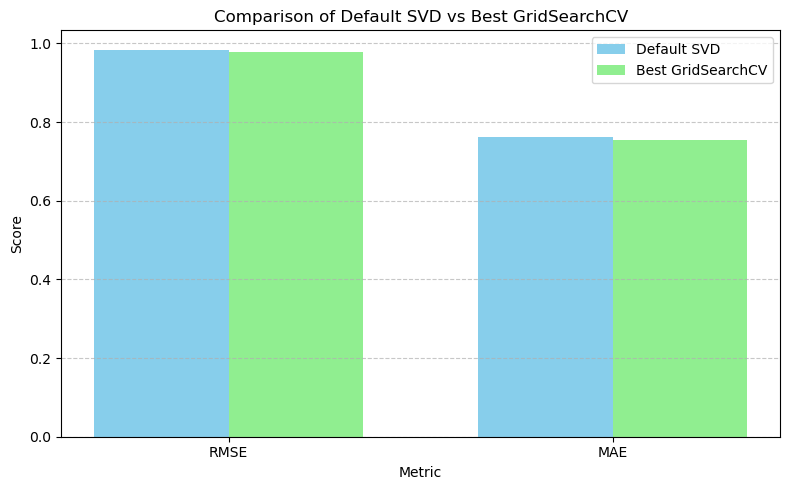

In [10]:
metrics = ['RMSE', 'MAE']
default_scores = [rmse_default, mae_default]
best_scores = [rmse_best, mae_best]

x = range(len(metrics))
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, default_scores, width=bar_width, label='Default SVD', color='skyblue')
plt.bar([p + bar_width for p in x], best_scores, width=bar_width, label='Best GridSearchCV', color='lightgreen')

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Comparison of Default SVD vs Best GridSearchCV')
plt.xticks([p + bar_width/2 for p in x], metrics)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

There is some improvement in both the metrics but not by a lot.